This notebook uses the data without the latest year
and training model based on rolling window
the rolling shouldn't include the on the day data as training
example: average 100, but an abnormal data comes in cause the average to 500 
then the model changed and think the abnormal data is normal 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_theme(style='darkgrid') #theme
pd.set_option('display.max_columns', None) # veiw all columns
pd.set_option('display.max_columns', None) # view all rows

%load_ext autoreload
%autoreload 2

In [2]:
data_raw = pd.read_csv('../data/processed/mhd_ch4_ml_v2.csv')
data_raw.tail(5)

/tmp/ipykernel_35919/3563110645.py:1: DtypeWarning: Columns (63) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv('../data/processed/mhd_ch4_ml_v2.csv')


,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal,year,month,day,hour,minute,seconds,psamp_roll_mean_10,pamb_roll_mean_10,pflow_roll_mean_10,tmod_roll_mean_10,psamp_roll_mean_100,pamb_roll_mean_100,pflow_roll_mean_100,tmod_roll_mean_100,psamp_roll_std_10,pamb_roll_std_10,pflow_roll_std_10,CH4_rt_roll_std_10,psamp_roll_std_100,pamb_roll_std_100,pflow_roll_std_100,CH4_rt_roll_std_100,psamp_diff_1,pflow_diff_1,CH4_area_diff_1,psamp_lag_1,pflow_lag_1
817950,260518,65300,std,J-286,J-286,3,0,40.0,22.06,NaN,813.5,752.32,NaN,752.4,77.8,3.98,133194.0,131007.0,0.50,73.0,99.8,99999.0,62297.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.649,NaN,2015.923,,,A,,0,0,0,260518065300,2026-05-18 06:53:00,False,False,False,False,26.8,False,-37702.0,1.016694,2026-05-18 06:13:00,2400.0,1,0,0,0,0,0,2026-04-28 06:18:00,1730100.0,2026,5,18,6,53,0,752.322,752.33,811.07,40.0,752.7259,752.700,811.938,40.0,0.100532,0.176698,2.445881,58.760792,0.525492,0.535601,2.558360,20.930976,0.01,-4.8,182060.0,752.26,808.6
817951,260518,71300,air,9m,J-286,1,9,40.0,22.32,NaN,808.6,752.28,NaN,752.2,79.0,4.57,160607.0,508996.0,0.46,73.0,102.0,99999.0,64464.0,1.02271,1.00491,1.00491,1.0227,1.0049,0.9981,1.02271,1.00491,1.00491,2061.71,2025.82,2025.82,3.649,3.666,2015.923,,,A,,0,0,0,260518071300,2026-05-18 07:13:00,False,False,False,False,29.0,False,-35535.0,0.315537,2026-05-18 06:13:00,3600.0,0,1,0,0,0,0,2026-04-28 06:18:00,1731300.0,2026,5,18,7,13,0,752.309,752.31,811.05,40.0,752.7119,752.686,811.921,40.0,0.089994,0.152388,2.422694,55.450498,0.517325,0.524745,2.542062,20.994550,0.06,4.9,-51053.0,752.32,813.5
817952,260518,73300,std,J-286,J-286,3,0,40.0,22.19,NaN,813.1,752.27,NaN,752.4,80.6,5.17,180892.0,882007.0,0.47,73.0,109.2,84204.0,66307.0,1.07106,1.34773,1.34773,1.0712,1.3480,1.0953,1.07106,1.34773,1.34773,2159.17,2716.92,2716.92,4.605,NaN,2015.923,,,A,,0,0,0,260518073300,2026-05-18 07:33:00,False,False,False,False,36.2,False,-17897.0,0.205091,2026-05-18 06:53:00,2400.0,1,0,0,0,0,0,2026-04-28 06:18:00,1732500.0,2026,5,18,7,33,0,752.294,752.28,811.00,40.0,752.6971,752.673,811.902,40.0,0.079470,0.139841,2.472066,51.803578,0.508126,0.520461,2.559829,21.047673,-0.04,-4.9,377989.0,752.28,808.6
817953,260518,75300,air,9m,J-286,1,9,40.0,22.10,NaN,808.2,752.13,NaN,752.2,80.4,5.01,186959.0,856303.0,0.41,73.0,106.6,87769.0,65923.0,0.97017,0.83156,NaN,0.9701,0.8315,0.9433,0.97017,0.83156,NaN,1955.78,1676.37,NaN,4.605,NaN,2015.923,*,*,A,,1,1,1,260518075300,2026-05-18 07:53:00,False,False,False,False,33.6,False,-21846.0,0.218333,2026-05-18 06:53:00,3600.0,0,1,0,0,0,0,2026-04-28 06:18:00,1733700.0,2026,5,18,7,53,0,752.272,752.27,810.96,40.0,752.6809,752.659,811.881,40.0,0.039665,0.125167,2.429998,46.793428,0.495375,0.508532,2.541045,21.088841,-0.01,4.5,373011.0,752.27,813.1
817954,260518,81300,std,J-286,J-286,3,0,40.0,22.23,NaN,813.3,752.09,NaN,752.0,82.0,5.46,204547.0,1177596.0,0.43,73.0,115.2,75876.0,68601.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.873,NaN,2015.923,,,A,,0,0,0,260518081300,2026-05-18 08:13:00,False,False,False,False,42.2,False,-7275.0,0.173699,2026-05-18 07:33:00,2400.0,1,0,0,0,0,0,2026-04-28 06:18:00,1734900.0,2026,5,18,8,13,0,752.249,752.27,810.90,40.0,752.6633,752.643,811.881,40.0,0.048637,0.125167,2.495774,40.690600,0.483096,0.497317,2.541045,21.130081,-0.14,-4.9,-25704.0,752.13,808.2


In [3]:
data = data_raw.copy()

In [4]:
data = data.sort_values('datetime')
data= data.reset_index(drop=True)
data.head()

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal,year,month,day,hour,minute,seconds,psamp_roll_mean_10,pamb_roll_mean_10,pflow_roll_mean_10,tmod_roll_mean_10,psamp_roll_mean_100,pamb_roll_mean_100,pflow_roll_mean_100,tmod_roll_mean_100,psamp_roll_std_10,pamb_roll_std_10,pflow_roll_std_10,CH4_rt_roll_std_10,psamp_roll_std_100,pamb_roll_std_100,pflow_roll_std_100,CH4_rt_roll_std_100,psamp_diff_1,pflow_diff_1,CH4_area_diff_1,psamp_lag_1,pflow_lag_1
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216142900,1994-02-16 14:29:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,14,29,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216144900,1994-02-16 14:49:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,14,49,0,761.100000,761.100000,841.900000,40.000000,761.100000,761.100000,841.900000,40.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,761.10,841.9
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,False,-34.0,0.384554,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,15,9,0,761.085000,761.150000,841.150000,40.000000,761.085000,761.150000,841.150000,40.000000,0.021213,0.070711,1.060660,0.000000,0.021213,0.070711,1.060660,0.000000,-0.03,-1.5,0.0,761.07,840.4
3,940216,152900,air,10m,G-024,3,10,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,0,0,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,False,0.0,0.142279,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,15,29,0,761.053333,761.066667,840.566667,40.003333,761.053333,761.066667,840.566667,40.003333,0.056862,0.152753,1.258306,63.393060,0.056862,0.152753,1.258306,63.393060,-0.08,-1.0,496440.0,760.99,839.4
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216180000,1994-02-16 18:00:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,18,0,0,761.030000,761.025000,840.325000,40.002500,761.030000,761.025000,840.325000,40.002500,0.065828,0.150000,1.135415,59.379542,0.065828,0.150000,1.135415,59.379542,-0.03,0.2,569542.0,760.96,839.6


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817955 entries, 0 to 817954
Data columns (total 92 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   date                    817955 non-null  int64  
 1   time                    817955 non-null  int64  
 2   type                    817954 non-null  object 
 3   sample                  817955 non-null  object 
 4   standard                817955 non-null  object 
 5   port                    817955 non-null  int64  
 6   ht                      817955 non-null  int64  
 7   tmod                    705671 non-null  float64
 8   tamb                    705671 non-null  float64
 9   lab_temp                0 non-null       float64
 10  pflow                   815553 non-null  float64
 11  psamp                   815626 non-null  float64
 12  ploop                   0 non-null       float64
 13  pamb                    815551 non-null  float64
 14  CH4_rt              

In [6]:
data[data['year']==2026].shape[0]

9744

data: include all years
data_update: without 2026 (latest year)

In [7]:
data_update = data.copy() 
data_update = data_update.drop(data_update[data_update['year']==2026].index)
data_update.tail()

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal,year,month,day,hour,minute,seconds,psamp_roll_mean_10,pamb_roll_mean_10,pflow_roll_mean_10,tmod_roll_mean_10,psamp_roll_mean_100,pamb_roll_mean_100,pflow_roll_mean_100,tmod_roll_mean_100,psamp_roll_std_10,pamb_roll_std_10,pflow_roll_std_10,CH4_rt_roll_std_10,psamp_roll_std_100,pamb_roll_std_100,pflow_roll_std_100,CH4_rt_roll_std_100,psamp_diff_1,pflow_diff_1,CH4_area_diff_1,psamp_lag_1,pflow_lag_1
808206,251231,223800,std,J-286,J-286,3,0,40.0,21.01,NaN,817.8,765.45,NaN,765.7,94.0,7.83,170066.0,1489856.0,1.16,80.8,133.4,23823.0,24073.0,1.00099,1.00067,1.00067,1.0010,1.0007,0.9997,1.00099,1.00067,1.00067,2017.92,2017.27,2017.27,2.406,NaN,2015.923,,,A,,0,0,0,251231223800,2025-12-31 22:38:00,False,False,False,False,52.6,False,250.0,0.114149,2025-12-31 21:57:00,2460.0,1,0,0,0,0,0,2025-12-28 06:16:00,318120.0,2025,12,31,22,38,0,766.407,766.33,816.44,40.0,772.0808,772.056,822.436,40.0,0.583306,0.586989,2.761320,0.10328,2.832881,2.881439,3.691583,0.094516,-0.47,-4.6,34189.0,765.37,813.7
808207,251231,225800,air,9m,J-286,1,9,40.0,20.74,NaN,813.2,765.28,NaN,765.2,94.0,7.85,171821.0,1508117.0,1.16,80.8,133.4,23750.0,24058.0,1.01178,1.01300,1.01300,1.0118,1.0130,1.0014,1.01178,1.01300,1.01300,2039.67,2042.12,2042.12,2.396,2.427,2015.923,,,A,,0,0,0,251231225800,2025-12-31 22:58:00,False,False,False,False,52.6,False,308.0,0.113931,2025-12-31 21:57:00,3660.0,0,1,0,0,0,0,2025-12-28 06:16:00,319320.0,2025,12,31,22,58,0,766.222,766.18,816.24,40.0,771.9890,771.966,822.381,40.0,0.561581,0.528730,2.555691,0.10328,2.897443,2.938020,3.719446,0.095219,0.08,4.1,-34481.0,765.45,817.8
808208,251231,231800,std,J-286,J-286,3,0,40.0,20.88,NaN,817.5,765.08,NaN,764.9,94.2,7.84,169569.0,1487622.0,1.06,80.8,133.6,23740.0,24030.0,0.99744,0.99876,0.99876,0.9973,0.9986,1.0015,0.99744,0.99876,0.99876,2010.76,2013.42,2013.42,2.413,NaN,2015.923,,,A,,0,0,0,251231231800,2025-12-31 23:18:00,False,False,False,False,52.8,False,290.0,0.113987,2025-12-31 22:38:00,2400.0,1,0,0,0,0,0,2025-12-28 06:16:00,320520.0,2025,12,31,23,18,0,766.039,766.00,816.19,40.0,771.8964,771.871,822.240,40.0,0.537720,0.524934,2.615106,0.10328,2.962336,3.001626,3.797527,0.095874,-0.17,-4.6,18261.0,765.28,813.2
808209,251231,233800,air,9m,J-286,1,9,40.0,20.79,NaN,813.3,765.05,NaN,765.0,94.2,7.86,170281.0,1496142.0,1.07,80.8,133.6,23756.0,24015.0,1.00289,1.00503,1.00503,1.0030,1.0051,1.0021,1.00289,1.00503,1.00503,2021.75,2026.06,2026.06,2.401,2.413,2015.923,,,A,,0,0,0,251231233800,2025-12-31 23:38:00,False,False,False,False,52.8,False,259.0,0.113813,2025-12-31 22:38:00,3600.0,0,1,0,0,0,0,2025-12-28 06:16:00,321720.0,2025,12,31,23,38,0,765.872,765.82,816.02,40.0,771.8028,771.775,822.179,40.0,0.551519,0.565292,2.447584,0.10328,3.028294,3.069445,3.824358,0.095874,-0.20,4.3,-20495.0,765.08,817.5
808210,251231,235800,std,J-286,J-286,3,0,NaN,NaN,NaN,817.4,764.90,NaN,NaN,94.2,7.83,169985.0,1489453.0,1.09,80.8,133.4,23691.0,24015.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.415,NaN,2015.923,,,A,,0,0,0,251231235800,2025-12-31 23:58:00,False,False,False,False,52.6,False,324.0,0.114126,2025-12-31 23:18:00,2400.0,1,0,0,0,0,0,2025-12-28 06:16:00,322920.0,2025,12,31,23,58,0,765.710,765.66,815.82,40.0,771.7077,771.680,822.040,40.0,0.528520,0.546097,2.590495,0.10328,3.089538,3.130656,3.892028,0.095874,-0.03,-4.2,8520.0,765.05,813.3


# ML

In [8]:
from sklearn.metrics import precision_recall_curve
def best_threshold(X_test, model, y_test):
    y_proba = model.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

    f1_scores = 2 * (precisions *recalls) / (precisions + recalls)

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    print(f"Best threshold: {best_threshold}")
    print(f"Best F1-score: {f1_scores[best_idx]:.4f}")
    print(f'Precision"{precisions[best_idx]:.4f}", Recall:{recalls[best_idx]}')

In [9]:
cols_all = [
    #'sample'	,'standard',	
    'port'	,'ht',
    'tmod'	,'tamb',
    'pflow', 'psamp',
    'pamb'	,
    'CH4_rt',	'CH4_w',	'CH4_ht'	,
    'CH4_area',	'CH4_skew'	,
    #'CH4_start_time',	'CH4_end_time'	,'CH4_start_level',	'CH4_end_level',
    #'CH4_Rl_ht',	'CH4_Rl_a',	'CH4_Rl',	
    #'CH4_norm_ht','CH4_norm_a',	'CH4_norm_w',
    #'CH4_R_ht','CH4_R_a', 'CH4_R'	,'
    #'CH4_C_ht'	,'CH4_C_a',	'CH4_C',	
    # std
    #'CH4_std_rep', 'CH4_std_rep'
    #'CH4_Cstd', 
    'is_ht_999', 'is_area_999', 'is_rt_zero', 'is_w_zero',
    'duration', 
    'is_duration_spike', 'baseline_drift', 'ht_area_ratio',
    'type_air', 'type_blank', 'type_cal', 'type_other', 'type_std', 'type_tank',
    #'year', 'month', 'day', 'hour', 'minute', 'seconds'
    'psamp_roll_mean_10', 'pamb_roll_mean_10', 'pflow_roll_std_10', 'tmod_roll_mean_10',
    'psamp_roll_std_10', 'pamb_roll_std_10', 'pflow_roll_std_10', 'CH4_rt_roll_std_10',
    
    'psamp_roll_mean_100', 'pamb_roll_mean_100', 'pflow_roll_std_100', 'tmod_roll_mean_100',
    'psamp_roll_std_100', 'pamb_roll_std_100', 'pflow_roll_std_100', 'CH4_rt_roll_std_100',
    'psamp_diff_1','pflow_diff_1', 'CH4_area_diff_1',
    'psamp_lag_1', 'pflow_lag_1'
]

In [10]:
feature_experiments = {
    'cols_all': cols_all
}

/home/ellie/research_project/notebooks/.venv/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


Model training...


2026/06/15 18:07:08 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
2026/06/15 18:07:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model training completed!
              precision    recall  f1-score   support

           0       0.94      0.99      0.96    144705
           1       0.85      0.42      0.56     16938

    accuracy                           0.93    161643
   macro avg       0.89      0.70      0.76    161643
weighted avg       0.93      0.93      0.92    161643



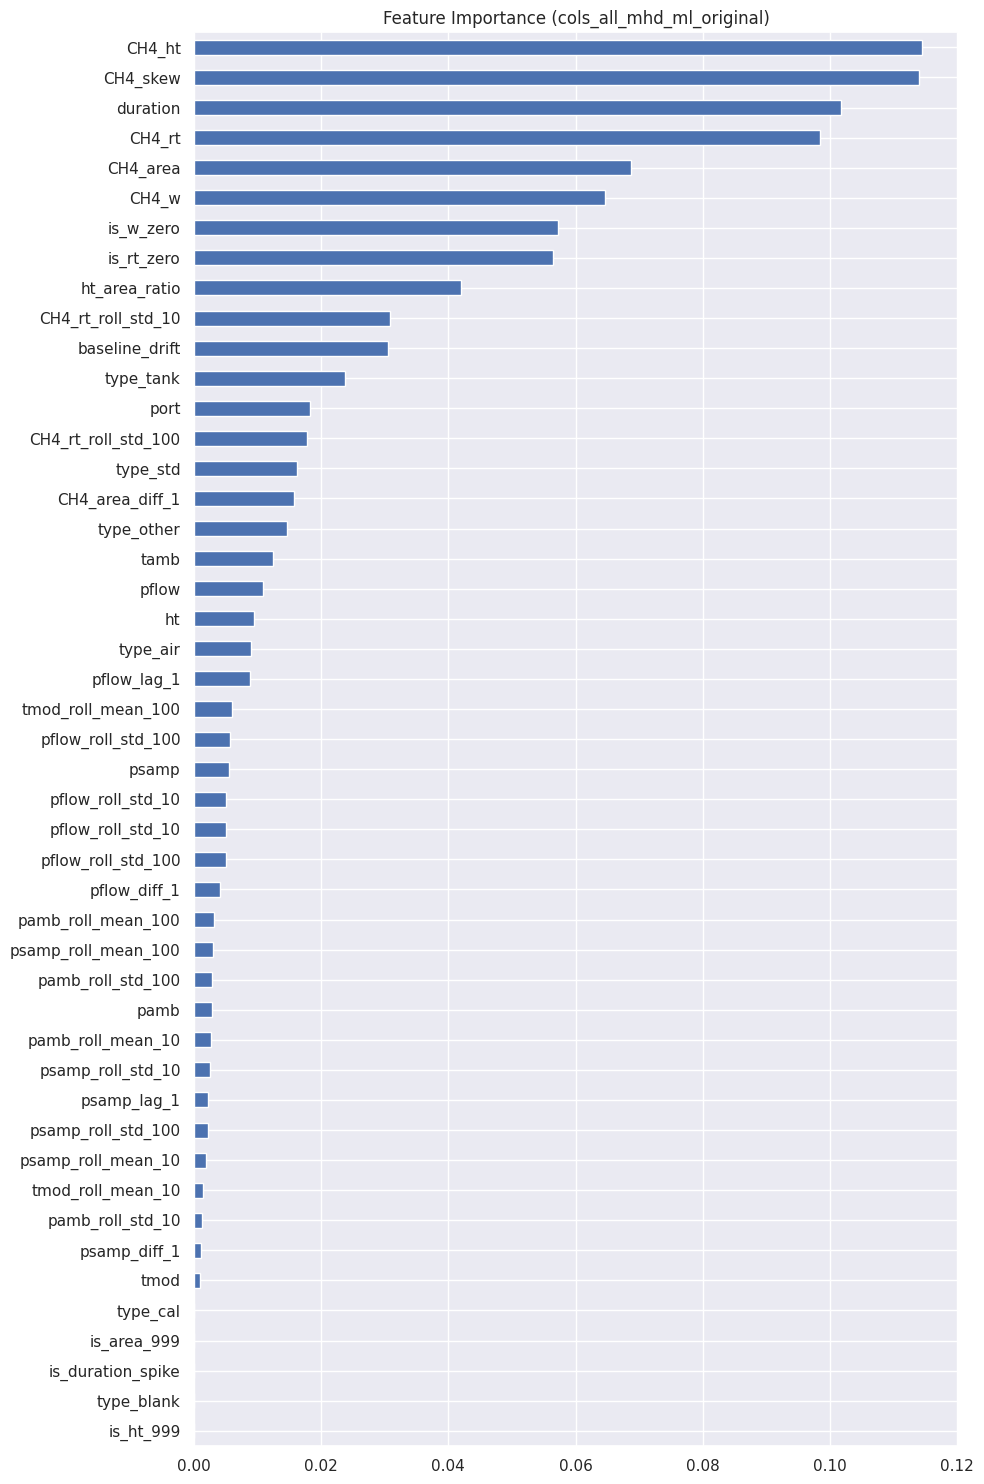

Best threshold: 0.18503396690466947
Best F1-score: 0.7217
Precision"0.7616", Recall:0.685795253276656


In [11]:
import mlflow
from sklearn.model_selection import train_test_split
from model import random_forest_model
for f, i in feature_experiments.items():
    X = data_update[i]
    y = data_update['label1']
    feature_cols = X.columns.tolist()
    split_idx = int(len(data_update)*0.8)

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    #median_vals = X_train.median()


    mlflow.set_experiment(f"{f}_mhd_ml_v3")
    print("Model training...")
    model = random_forest_model(
        X_train, y_train, X_test, y_test,
        feature_names=feature_cols,
        experiment_run_name=f"{f}_mhd_ml_original", n_estimators=200, max_depth=12, n_jobs=-1,
        threshold =0.5, class_weight=None
    )
    best_threshold(X_test, model, y_test)


Model training...


2026/06/15 18:08:57 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
2026/06/15 18:08:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model training completed!
              precision    recall  f1-score   support

           0       0.96      0.04      0.07    144705
           1       0.11      0.99      0.19     16938

    accuracy                           0.14    161643
   macro avg       0.53      0.51      0.13    161643
weighted avg       0.87      0.14      0.09    161643



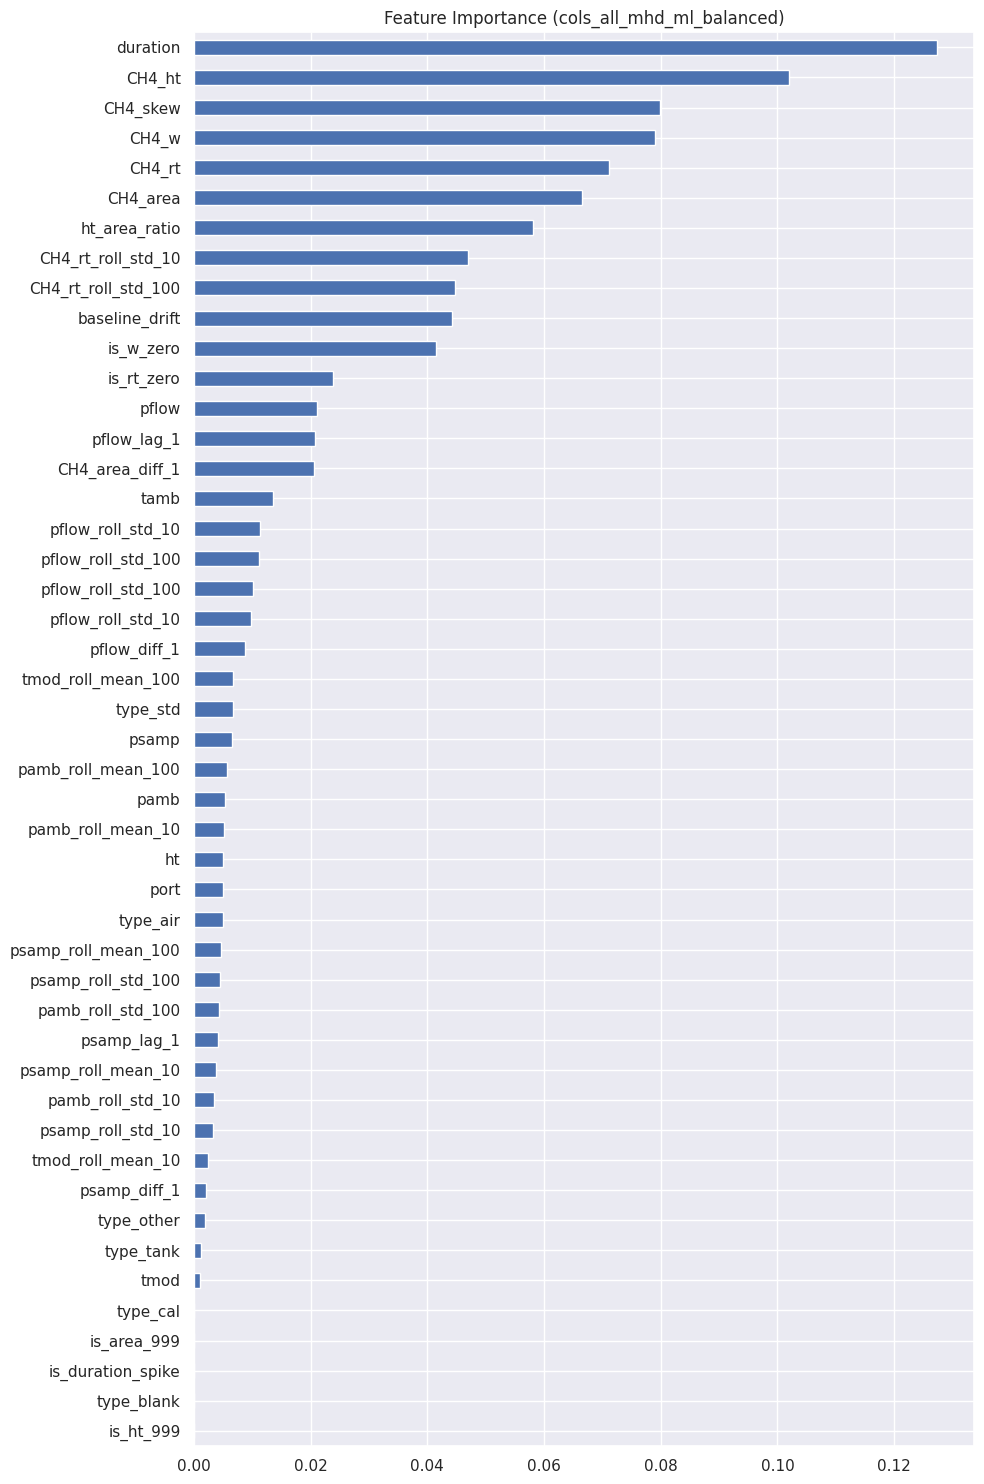

Best threshold: 0.4759774937629355
Best F1-score: 0.6448
Precision"0.7678", Recall:0.5557917109458024


In [12]:
# add class_weight = 'balanced'
import mlflow
from sklearn.model_selection import train_test_split
from model import random_forest_model
for f, i in feature_experiments.items():
    X = data_update[i]
    y = data_update['label1']
    feature_cols = X.columns.tolist()
    split_idx = int(len(data_update)*0.8)

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    #median_vals = X_train.median()


    mlflow.set_experiment(f"{f}_mhd_ml_v3")
    print("Model training...")
    model = random_forest_model(
        X_train, y_train, X_test, y_test,
        feature_names=feature_cols,
        experiment_run_name=f"{f}_mhd_ml_balanced", n_estimators=200, max_depth=12, n_jobs=-1,
        threshold =0.15444925025298545, class_weight='balanced'
    )
    best_threshold(X_test, model, y_test)

##view first tree
from sklearn.tree import export_graphviz
export_graphviz(model.estimators_[0], out_file='tree.dot', feature_names = cols_all)

**add more lag data**

In [29]:
cols_all = [
    #'sample'	,'standard',	
    'port'	,'ht',
    'tmod'	,'tamb',
    'pflow', 'psamp',
    'pamb'	,
    'CH4_rt',	'CH4_w',	'CH4_ht'	,
    'CH4_area',	'CH4_skew'	,
    #'CH4_start_time',	'CH4_end_time'	,'CH4_start_level',	'CH4_end_level',
    #'CH4_Rl_ht',	'CH4_Rl_a',	'CH4_Rl',	
    #'CH4_norm_ht','CH4_norm_a',	'CH4_norm_w',
    #'CH4_R_ht','CH4_R_a', 'CH4_R'	,'
    #'CH4_C_ht'	,'CH4_C_a',	'CH4_C',	
    # std
    #'CH4_std_rep', 'CH4_std_rep'
    #'CH4_Cstd', 
    'is_ht_999', 'is_area_999', 'is_rt_zero', 'is_w_zero',
    'duration', 
    #'is_duration_spike',
    'baseline_drift', 'ht_area_ratio',
    'type_air', 'type_blank', 'type_cal', 'type_other', 'type_std', 'type_tank',
    #'year', 'month', 'day', 'hour', 'minute', 'seconds'
    'psamp_roll_mean_10', 'pamb_roll_mean_10', 'pflow_roll_std_10', 'tmod_roll_mean_10',
    'psamp_roll_std_10', 'pamb_roll_std_10', 'pflow_roll_std_10', 'CH4_rt_roll_std_10',
    
    'psamp_roll_mean_100', 'pamb_roll_mean_100', 'pflow_roll_std_100', 'tmod_roll_mean_100',
    'psamp_roll_std_100', 'pamb_roll_std_100', 'pflow_roll_std_100', 'CH4_rt_roll_std_100',
    'psamp_diff_1','pflow_diff_1', 'CH4_area_diff_1',
    'psamp_lag_1', 'pflow_lag_1',

    'psamp_lag_2','pflow_lag_2','tmod_lag_1','tmod_lag_2','tamb_lag_1','tamb_lag_2',	
    'CH4_rt_lag_1','CH4_rt_lag_2','CH4_w_lag_1','CH4_w_lag_2','CH4_ht_lag_1', 'CH4_ht_lag_2','CH4_area_lag_1','CH4_area_lag_2','CH4_skew_lag_1','CH4_skew_lag_2'
]

In [30]:
feature_experiments = {
    'cols_all': cols_all
}

In [19]:
data_ml_v1 =data_update.copy()
data_ml_v1.head()

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal,year,month,day,hour,minute,seconds,psamp_roll_mean_10,pamb_roll_mean_10,pflow_roll_mean_10,tmod_roll_mean_10,psamp_roll_mean_100,pamb_roll_mean_100,pflow_roll_mean_100,tmod_roll_mean_100,psamp_roll_std_10,pamb_roll_std_10,pflow_roll_std_10,CH4_rt_roll_std_10,psamp_roll_std_100,pamb_roll_std_100,pflow_roll_std_100,CH4_rt_roll_std_100,psamp_diff_1,pflow_diff_1,CH4_area_diff_1,psamp_lag_1,pflow_lag_1
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216142900,1994-02-16 14:29:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,14,29,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216144900,1994-02-16 14:49:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,14,49,0,761.100000,761.100000,841.900000,40.000000,761.100000,761.100000,841.900000,40.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,761.10,841.9
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,False,-34.0,0.384554,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,15,9,0,761.085000,761.150000,841.150000,40.000000,761.085000,761.150000,841.150000,40.000000,0.021213,0.070711,1.060660,0.000000,0.021213,0.070711,1.060660,0.000000,-0.03,-1.5,0.0,761.07,840.4
3,940216,152900,air,10m,G-024,3,10,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,0,0,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,False,0.0,0.142279,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,15,29,0,761.053333,761.066667,840.566667,40.003333,761.053333,761.066667,840.566667,40.003333,0.056862,0.152753,1.258306,63.393060,0.056862,0.152753,1.258306,63.393060,-0.08,-1.0,496440.0,760.99,839.4
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216180000,1994-02-16 18:00:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,18,0,0,761.030000,761.025000,840.325000,40.002500,761.030000,761.025000,840.325000,40.002500,0.065828,0.150000,1.135415,59.379542,0.065828,0.150000,1.135415,59.379542,-0.03,0.2,569542.0,760.96,839.6


In [20]:
data_ml_v1 = data_ml_v1.drop(columns=['last_std_time', 'seconds_since_last_std', 'last_cal_time', 'seconds_since_last_cal', 'is_duration_spike'])

In [21]:
data_ml_v1.head()

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,baseline_drift,ht_area_ratio,type_std,type_air,type_tank,type_blank,type_cal,type_other,year,month,day,hour,minute,seconds,psamp_roll_mean_10,pamb_roll_mean_10,pflow_roll_mean_10,tmod_roll_mean_10,psamp_roll_mean_100,pamb_roll_mean_100,pflow_roll_mean_100,tmod_roll_mean_100,psamp_roll_std_10,pamb_roll_std_10,pflow_roll_std_10,CH4_rt_roll_std_10,psamp_roll_std_100,pamb_roll_std_100,pflow_roll_std_100,CH4_rt_roll_std_100,psamp_diff_1,pflow_diff_1,CH4_area_diff_1,psamp_lag_1,pflow_lag_1
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216142900,1994-02-16 14:29:00,False,False,True,True,0.0,0.0,NaN,0,1,0,0,0,0,1994,2,16,14,29,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216144900,1994-02-16 14:49:00,False,False,True,True,0.0,0.0,NaN,0,1,0,0,0,0,1994,2,16,14,49,0,761.100000,761.100000,841.900000,40.000000,761.100000,761.100000,841.900000,40.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,761.10,841.9
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,-34.0,0.384554,0,1,0,0,0,0,1994,2,16,15,9,0,761.085000,761.150000,841.150000,40.000000,761.085000,761.150000,841.150000,40.000000,0.021213,0.070711,1.060660,0.000000,0.021213,0.070711,1.060660,0.000000,-0.03,-1.5,0.0,761.07,840.4
3,940216,152900,air,10m,G-024,3,10,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,0,0,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,0.0,0.142279,0,1,0,0,0,0,1994,2,16,15,29,0,761.053333,761.066667,840.566667,40.003333,761.053333,761.066667,840.566667,40.003333,0.056862,0.152753,1.258306,63.393060,0.056862,0.152753,1.258306,63.393060,-0.08,-1.0,496440.0,760.99,839.4
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216180000,1994-02-16 18:00:00,False,False,True,True,0.0,0.0,NaN,0,1,0,0,0,0,1994,2,16,18,0,0,761.030000,761.025000,840.325000,40.002500,761.030000,761.025000,840.325000,40.002500,0.065828,0.150000,1.135415,59.379542,0.065828,0.150000,1.135415,59.379542,-0.03,0.2,569542.0,760.96,839.6


curent lag: psamp_lag_1, pflow_lag_1
lag choose: tmod, tamb, CH4_rt, CH4_w, CH4_ht, CH4_area, CH4_skew


In [23]:
lag_list = ['psamp', 'pflow', 'tmod', 'tamb', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew']
for i in lag_list:
    data_ml_v1[f'{i}_lag_1'] = data_ml_v1[f'{i}'].shift(1)
    data_ml_v1[f'{i}_lag_2'] = data_ml_v1[f'{i}'].shift(2)
data_ml_v1.head()

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,baseline_drift,ht_area_ratio,type_std,type_air,type_tank,type_blank,type_cal,type_other,year,month,day,hour,minute,seconds,psamp_roll_mean_10,pamb_roll_mean_10,pflow_roll_mean_10,tmod_roll_mean_10,psamp_roll_mean_100,pamb_roll_mean_100,pflow_roll_mean_100,tmod_roll_mean_100,psamp_roll_std_10,pamb_roll_std_10,pflow_roll_std_10,CH4_rt_roll_std_10,psamp_roll_std_100,pamb_roll_std_100,pflow_roll_std_100,CH4_rt_roll_std_100,psamp_diff_1,pflow_diff_1,CH4_area_diff_1,psamp_lag_1,pflow_lag_1,psamp_lag_2,pflow_lag_2,tmod_lag_1,tmod_lag_2,tamb_lag_1,tamb_lag_2,CH4_rt_lag_1,CH4_rt_lag_2,CH4_w_lag_1,CH4_w_lag_2,CH4_ht_lag_1,CH4_ht_lag_2,CH4_area_lag_1,CH4_area_lag_2,CH4_skew_lag_1,CH4_skew_lag_2
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216142900,1994-02-16 14:29:00,False,False,True,True,0.0,0.0,NaN,0,1,0,0,0,0,1994,2,16,14,29,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216144900,1994-02-16 14:49:00,False,False,True,True,0.0,0.0,NaN,0,1,0,0,0,0,1994,2,16,14,49,0,761.100000,761.100000,841.900000,40.000000,761.100000,761.100000,841.900000,40.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,761.10,841.9,NaN,NaN,40.00,NaN,32.27,NaN,0.0,NaN,0.00,NaN,0.0,NaN,0.0,NaN,0.00,NaN
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,-34.0,0.384554,0,1,0,0,0,0,1994,2,16,15,9,0,761.085000,761.150000,841.150000,40.000000,761.085000,761.150000,841.150000,40.000000,0.021213,0.070711,1.060660,0.000000,0.021213,0.070711,1.060660,0.000000,-0.03,-1.5,0.0,761.07,840.4,761.10,841.9,40.00,40.00,32.48,32.27,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00
3,940216,152900,air,10m,G-024,3,10,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,0,0,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,0.0,0.142279,0,1,0,0,0,0,1994,2,16,15,29,0,761.053333,761.066667,840.566667,40.003333,761.053333,761.066667,840.566667,40.003333,0.056862,0.152753,1.258306,63.393060,0.056862,0.152753,1.258306,63.393060,-0.08,-1.0,496440.0,760.99,839.4,761.07,840.4,40.01,40.00,32.75,32.48,109.8,0.0,2.60,0.0,190908.0,0.0,496440.0,0.0,0.63,0.00
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216180000,1994-02-16 18:00:00,False,False,True,True,0.0,0.0,NaN,0,1,0,0,0,0,1994,2,16,18,0,0,761.030000,761.025000,840.325000,40.002500,761.030000,761.025000,840.325000,40.002500,0.065828,0.150000,1.135415,59.379542,0.065828,0.150000,1.135415,59.379542,-0.03,0.2,569542.0,760.96,839.6,760.99,839.4,40.00,40.01,32.92,32.75,94.8,109.8,6.85,2.6,151667.0,190908.0,1065982.0,496440.0,1.02,0.63


2026/06/15 18:41:25 INFO mlflow.tracking.fluent: Experiment with name 'cols_all_mhd_ml_v4' does not exist. Creating a new experiment.


Model training...


2026/06/15 18:43:04 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
2026/06/15 18:43:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model training completed!
              precision    recall  f1-score   support

           0       0.93      0.99      0.96    144705
           1       0.87      0.39      0.53     16938

    accuracy                           0.93    161643
   macro avg       0.90      0.69      0.75    161643
weighted avg       0.93      0.93      0.92    161643



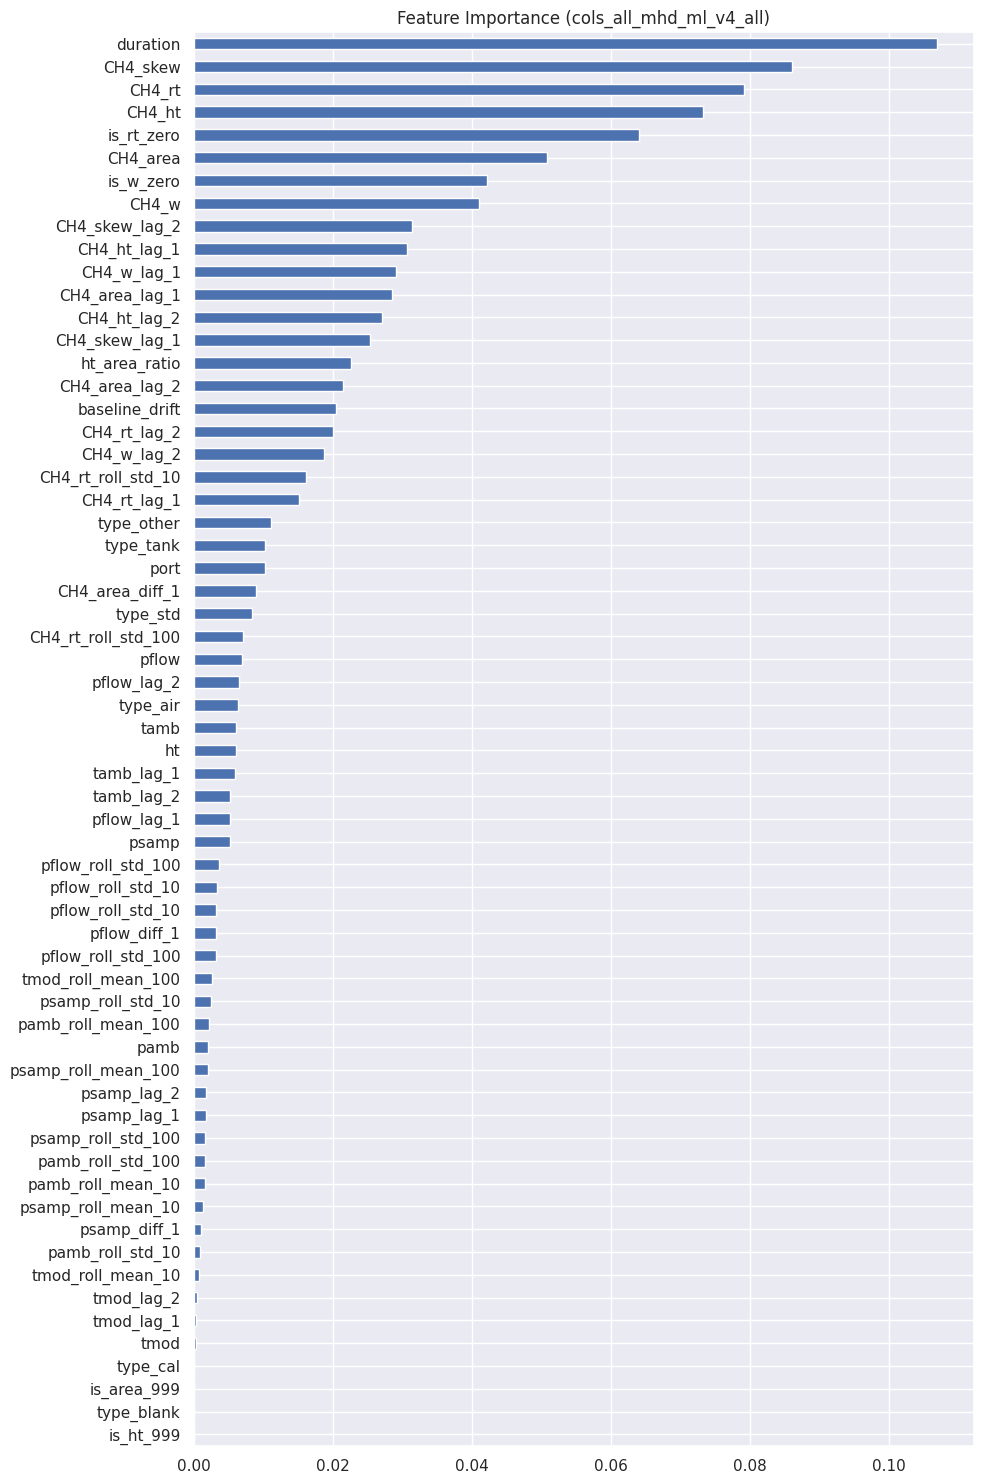

Best threshold: 0.22829410460460328
Best F1-score: 0.7269
Precision"0.7845", Recall:0.6771755815326485


In [31]:
import mlflow
from sklearn.model_selection import train_test_split
from model import random_forest_model

for f, i in feature_experiments.items():
    X = data_ml_v1[i]
    y = data_ml_v1['label1']
    feature_cols = X.columns.tolist()
    split_idx = int(len(data_ml_v1)*0.8)

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    mlflow.set_experiment(f'{f}_mhd_ml_v4') # v4
    print("Model training...")
    model = random_forest_model(
        X_train, y_train, X_test, y_test,
        feature_names=feature_cols,
        experiment_run_name=f'{f}_mhd_ml_v4_all', n_estimators=200, max_depth=12, n_jobs=-1,
        threshold=0.5,class_weight=None
    )
    best_threshold(X_test, model, y_test)


Model training...


2026/06/15 22:11:03 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
2026/06/15 22:11:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model training completed!
              precision    recall  f1-score   support

           0       0.94      0.99      0.96    144705
           1       0.88      0.43      0.57     16938

    accuracy                           0.93    161643
   macro avg       0.91      0.71      0.77    161643
weighted avg       0.93      0.93      0.92    161643



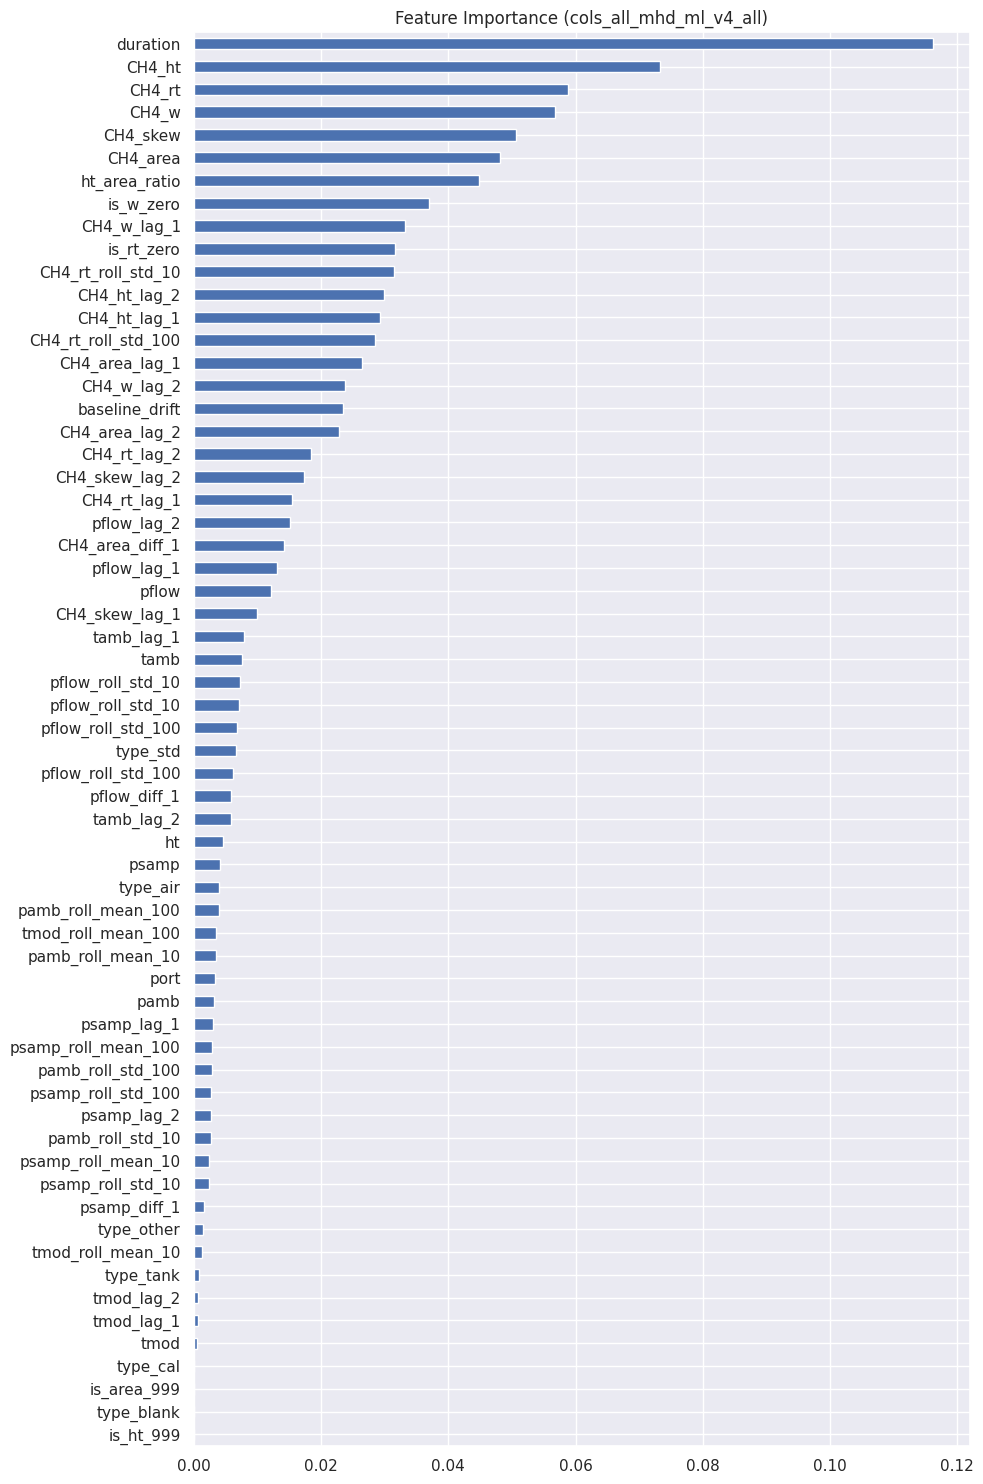

Best threshold: 0.4351529875586918
Best F1-score: 0.6457
Precision"0.7688", Recall:0.5565592159641044


In [32]:
# add calss_weight = 'balanced'
import mlflow
from sklearn.model_selection import train_test_split
from model import random_forest_model

for f, i in feature_experiments.items():
    X = data_ml_v1[i]
    y = data_ml_v1['label1']
    feature_cols = X.columns.tolist()
    split_idx = int(len(data_ml_v1)*0.8)

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    mlflow.set_experiment(f'{f}_mhd_ml_v4') # v4
    print("Model training...")
    model = random_forest_model(
        X_train, y_train, X_test, y_test,
        feature_names=feature_cols,
        experiment_run_name=f'{f}_mhd_ml_v4_all', n_estimators=200, max_depth=12, n_jobs=-1,
        threshold=0.5,class_weight='balanced'
    )
    best_threshold(X_test, model, y_test)

The inclusion of class_weight didn't improve the Random Forest's performance
making the model too conservative